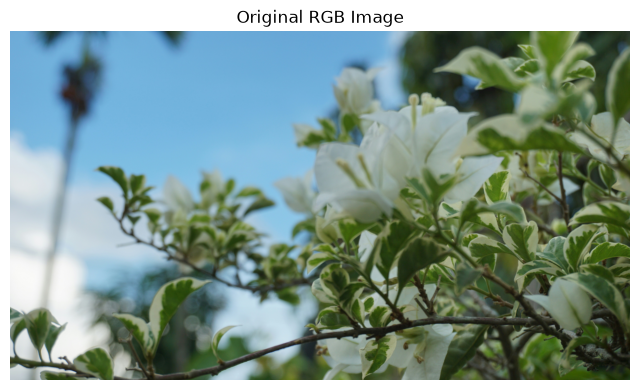

In [2]:
#1) Load the RGB image and visualize it.

import cv2
import matplotlib.pyplot as plt
image = cv2.imread("image.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()

Red Channel   - Mean: 110.069016  Standard Deviation: 49.37796
Green Channel - Mean: 136.40607  Standard Deviation: 53.777927
Blue Channel  - Mean: 127.927505  Standard Deviation: 77.91371


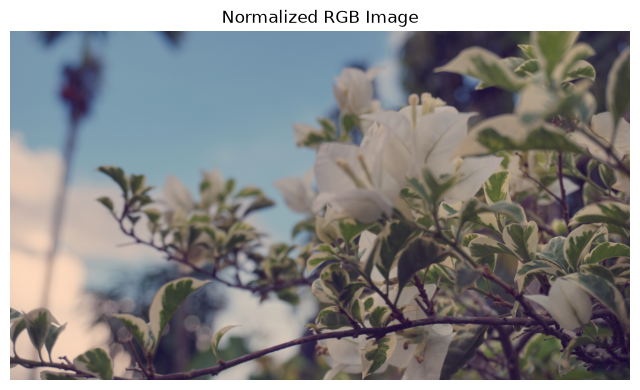

In [3]:
"""2) Calculate the mean and standard deviation of each color channel of the image.
Normalize each pixel by subtracting the corresponding channel mean and dividing by
its standard deviation. Visualize the resulting normalized image"""
import numpy as np
image_float = image_rgb.astype(np.float32)

mean_R = np.mean(image_float[:, :, 0])
mean_G = np.mean(image_float[:, :, 1])
mean_B = np.mean(image_float[:, :, 2])

std_R = np.std(image_float[:, :, 0])
std_G = np.std(image_float[:, :, 1])
std_B = np.std(image_float[:, :, 2])

print("Red Channel   - Mean:", mean_R, " Standard Deviation:", std_R)
print("Green Channel - Mean:", mean_G, " Standard Deviation:", std_G)
print("Blue Channel  - Mean:", mean_B, " Standard Deviation:", std_B)

normalized_R = (image_float[:, :, 0] - mean_R) / std_R
normalized_G = (image_float[:, :, 1] - mean_G) / std_G
normalized_B = (image_float[:, :, 2] - mean_B) / std_B

normalized_image = np.stack(
    (normalized_R, normalized_G, normalized_B),
    axis=2
)

normalized_display = cv2.normalize(
    normalized_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

plt.figure(figsize=(8, 6))
plt.imshow(normalized_display)
plt.title("Normalized RGB Image")
plt.axis("off")
plt.show()

In [4]:

# 3) Print the dimensions (Height, Width, Channels), data type and total pixels of the image.
height, width, channels = image_rgb.shape

total_pixels = height * width
print("Image Dimensions:")
print("Height   :", height)
print("Width    :", width)
print("Channels :", channels)

print("\nData Type:", image_rgb.dtype)

print("Total Pixels:", total_pixels)

Image Dimensions:
Height   : 3376
Width    : 6000
Channels : 3

Data Type: uint8
Total Pixels: 20256000


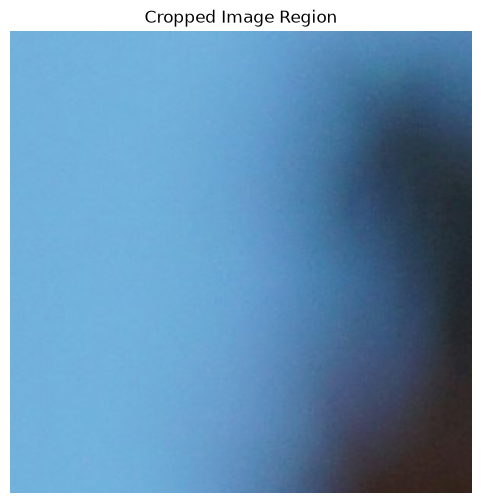

In [ ]:
#4) Select a small region from the image and visualize it. (Image Cropping)
y1 = 300
y2 = 600
x1 = 300
x2 = 600

cropped_image = image_rgb[y1:y2, x1:x2]

plt.figure(figsize=(6, 6))
plt.imshow(cropped_image)
plt.title("Cropped Image Region")
plt.axis("off")
plt.show()

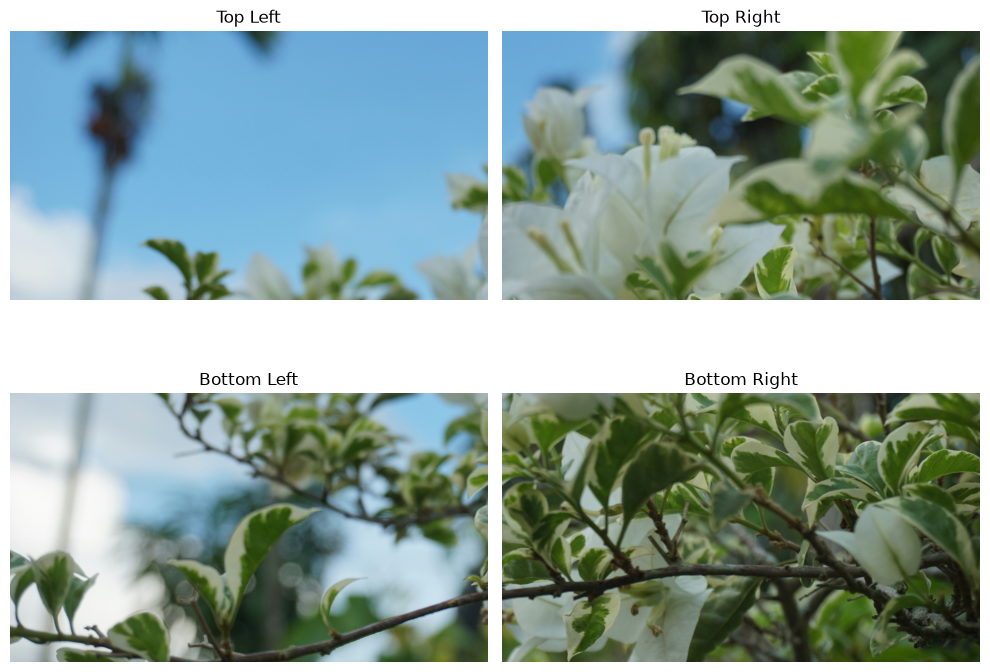

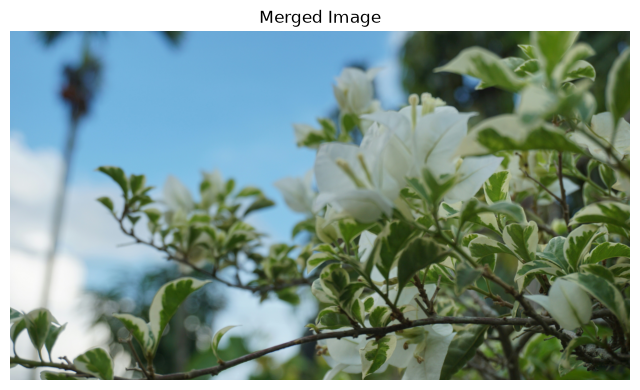

In [ ]:
# 5) Split the images into four equal parts and visualize each one of them. Merge these splitted parts of the image.
mid_height = height // 2
mid_width = width // 2

top_left = image_rgb[0:mid_height, 0:mid_width]
top_right = image_rgb[0:mid_height, mid_width:width]
bottom_left = image_rgb[mid_height:height, 0:mid_width]
bottom_right = image_rgb[mid_height:height, mid_width:width]

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(top_left)
plt.title("Top Left")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(top_right)
plt.title("Top Right")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(bottom_left)
plt.title("Bottom Left")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(bottom_right)
plt.title("Bottom Right")
plt.axis("off")

plt.tight_layout()
plt.show()

top_half = np.hstack((top_left, top_right))
bottom_half = np.hstack((bottom_left, bottom_right))

merged_image = np.vstack((top_half, bottom_half))

plt.figure(figsize=(8, 6))
plt.imshow(merged_image)
plt.title("Merged Image")
plt.axis("off")
plt.show()

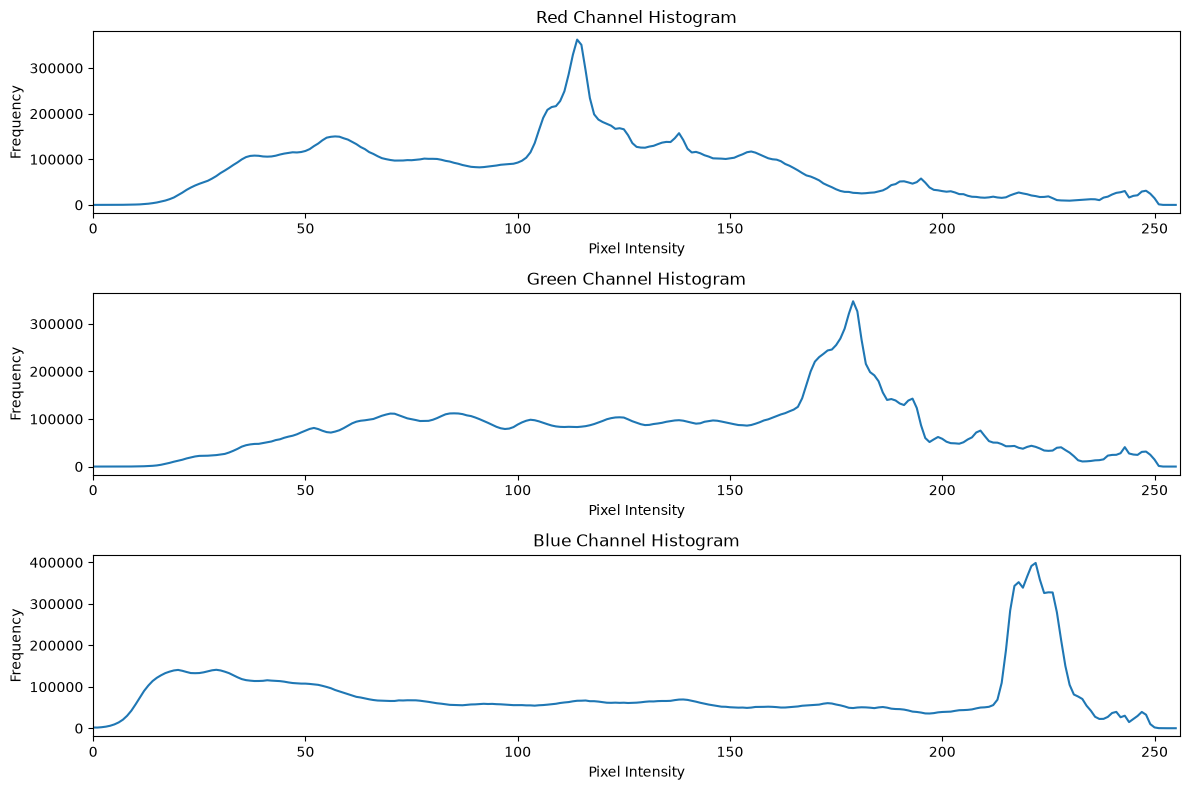

In [ ]:
# 6) Compute the histogram of the image and plot the histogram of each color channel
red_histogram = cv2.calcHist([image_rgb], [0], None, [256], [0, 256])
green_histogram = cv2.calcHist([image_rgb], [1], None, [256], [0, 256])
blue_histogram = cv2.calcHist([image_rgb], [2], None, [256], [0, 256])

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(red_histogram)
plt.title("Red Channel Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.subplot(3, 1, 2)
plt.plot(green_histogram)
plt.title("Green Channel Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.subplot(3, 1, 3)
plt.plot(blue_histogram)
plt.title("Blue Channel Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

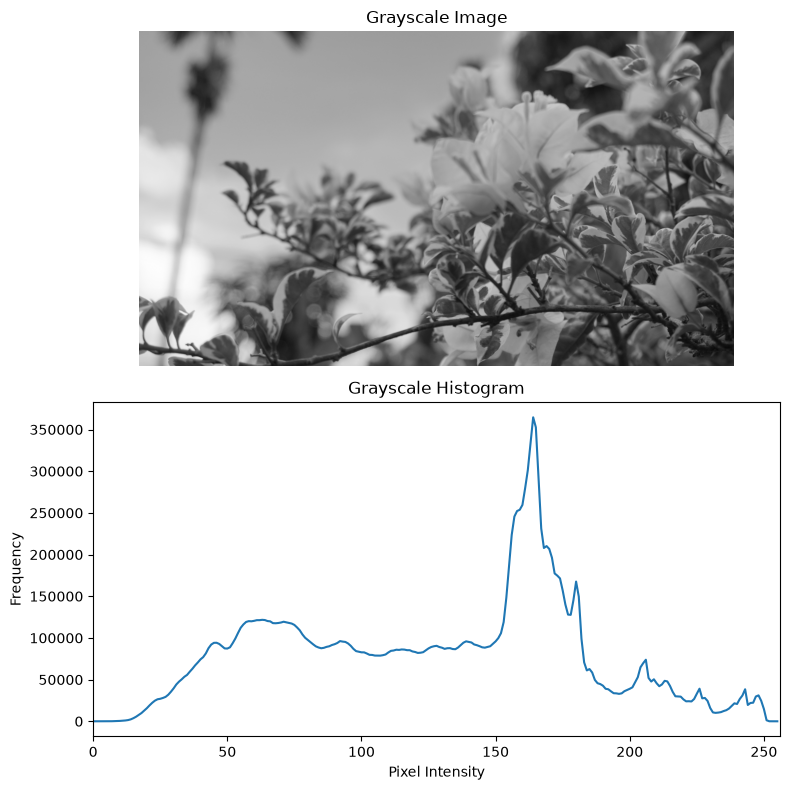

In [5]:
# 7) Convert the image to grayscale and plot its histogram
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Calculate the grayscale histogram
gray_histogram = cv2.calcHist(
    [gray_image],
    [0],
    None,
    [256],
    [0, 256]
)

# Display the grayscale image and histogram one below the other
plt.figure(figsize=(8, 8))

# Grayscale image
plt.subplot(2, 1, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

# Histogram
plt.subplot(2, 1, 2)
plt.plot(gray_histogram)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

Original Image Shape: (3376, 6000, 3)
Zoomed In (2x) Shape: (6752, 12000, 3)
Zoomed Out (2x) Shape: (1688, 3000, 3)


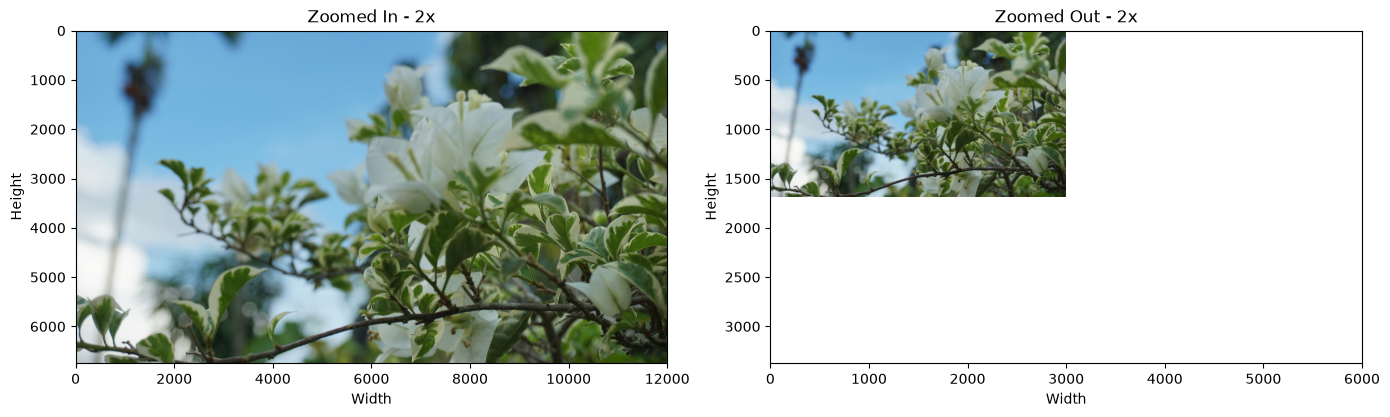

In [ ]:
# 8) Zoom the image by 2x and Zoom out by 2x visualize both of these images side by side. Print the shapes of these modified images

zoom_in = cv2.resize(
    image_rgb,
    None,
    fx=2,
    fy=2,
    interpolation=cv2.INTER_LINEAR
)

zoom_out = cv2.resize(
    image_rgb,
    None,
    fx=0.5,
    fy=0.5,
    interpolation=cv2.INTER_AREA
)

height, width, channels = image_rgb.shape

print("Original Image Shape:", image_rgb.shape)
print("Zoomed In (2x) Shape:", zoom_in.shape)
print("Zoomed Out (2x) Shape:", zoom_out.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(
    zoom_in,
    extent=[0, width * 2, height * 2, 0]
)

axes[0].set_xlim(0, width * 2)
axes[0].set_ylim(height * 2, 0)

axes[0].set_title("Zoomed In - 2x")
axes[0].set_xlabel("Width")
axes[0].set_ylabel("Height")

axes[1].imshow(
    zoom_out,
    extent=[0, width * 0.5, height * 0.5, 0]
)

axes[1].set_xlim(0, width)
axes[1].set_ylim(height, 0)

axes[1].set_title("Zoomed Out - 2x")
axes[1].set_xlabel("Width")
axes[1].set_ylabel("Height")

plt.tight_layout()
plt.show()

Original Image Shape : (3376, 6000, 3)
Pyramid Level 1 Shape: (1688, 3000, 3)
Pyramid Level 2 Shape: (844, 1500, 3)
Pyramid Level 3 Shape: (422, 750, 3)


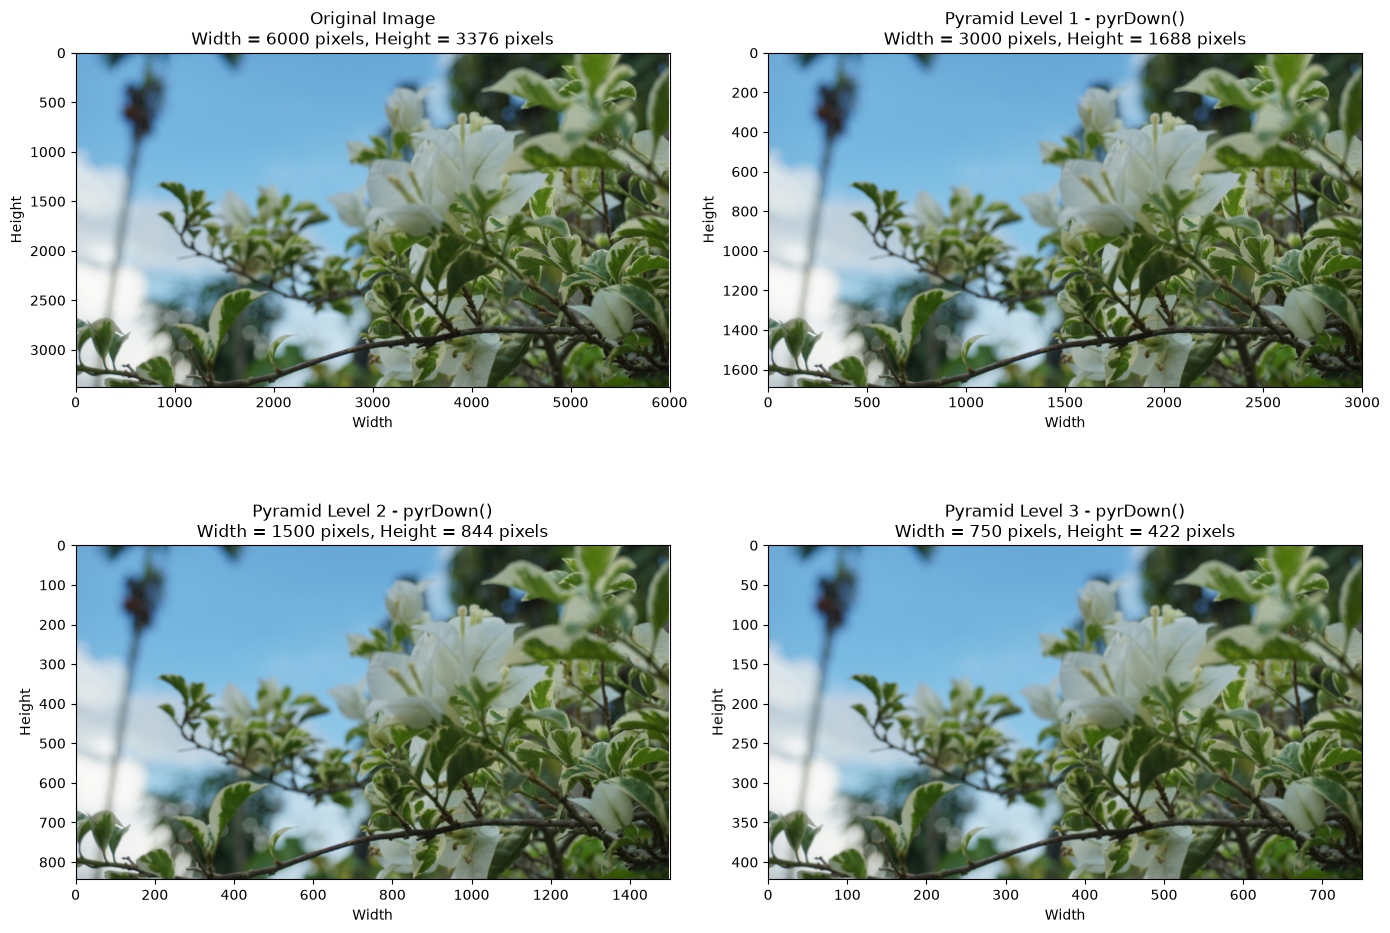

In [ ]:
#9) Building pyramids - Resize the image to a different Heights, Widths and visualize itusing cv2.pyrDown()
pyramid_1 = cv2.pyrDown(image_rgb)
pyramid_2 = cv2.pyrDown(pyramid_1)
pyramid_3 = cv2.pyrDown(pyramid_2)

print("Original Image Shape :", image_rgb.shape)
print("Pyramid Level 1 Shape:", pyramid_1.shape)
print("Pyramid Level 2 Shape:", pyramid_2.shape)
print("Pyramid Level 3 Shape:", pyramid_3.shape)


images = [
    (image_rgb, "Original Image"),
    (pyramid_1, "Pyramid Level 1 - pyrDown()"),
    (pyramid_2, "Pyramid Level 2 - pyrDown()"),
    (pyramid_3, "Pyramid Level 3 - pyrDown()")
]

plt.figure(figsize=(14, 10))

for i, (img, title) in enumerate(images, 1):

    height, width = img.shape[:2]

    plt.subplot(2, 2, i)

    plt.imshow(img)


    plt.title(
        f"{title}\n"
        f"Width = {width} pixels, Height = {height} pixels"
    )


    plt.xlabel("Width")
    plt.ylabel("Height")


    plt.axis("on")

    plt.xlim(0, width)
    plt.ylim(height, 0)

plt.tight_layout()
plt.show()